<a href="https://colab.research.google.com/github/renatofb98/Data_science_projects/blob/main/Predi%C3%A7%C3%A3o%20de%20Risco%20de%20Impedimento%20de%20Gest%C3%A3o%20no%20IGDM%20dos%20Munic%C3%ADpios%20de%20Goi%C3%A1s.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import requests
import sqlite3

# vamos usar a API do CKAN (motor por trás do dados.gov.br) pra achar o link direto do arquivo,
# em vez de depender da interface que exige JS

In [ ]:
url = "https://dados.gov.br/api/3/action/package_show"
params = {"id": "indice-de-gestao-descentralizada-dos-municipios---igd-m"}

resp = requests.get(url, params=params)

# Check if the request was successful
if resp.status_code == 200:
    data = resp.json()

    # lista os recursos (arquivos) disponíveis nesse dataset
    for r in data["result"]["resources"]:
        print(r["name"], "->", r["url"])
else:
    print(f"Error: Request failed with status code {resp.status_code}")
    print("Response content:")
    print(resp.text)

Error: Request failed with status code 401
Response content:



You can test the API endpoint directly in your browser:

```
https://dados.gov.br/api/3/action/package_show?id=indice-de-gestao-descentralizada-dos-municipios---igd-m
```

If you still encounter a 401 Unauthorized error in the browser, it confirms an issue with accessing this specific resource or the API itself. If it works in the browser but not in Colab, there might be other environmental factors at play.

In [ ]:
import pandas as pd

# The original URLs had unencoded spaces and square brackets in the 'anomes_s' filter.
# These need to be properly URL-encoded as per HTTP standards.
# Specifically, '[201801 TO 202612]' should become '%5B201801%20TO%20202612%5D'.

url_taxas_base = "https://aplicacoes.mds.gov.br/sagi/servicos/misocial/?q=*&fq=anomes_s:%5B201801%20TO%20202612%5D&fq=codigo_ibge:52*&fl=codigo_ibge%2Canomes_s%20tx_acomp_freq_escol_f%20tx_acomp_agenda_saude_f%20tx_atual_cad_f%20igdm_f%20igd_pbf_fator_redutor_conforme_saldo_f&fq=igdm_f%3A*&q=*%3A*&rows={rows}&sort=anomes_s%20desc%2C%20codigo_ibge%20asc&wt=csv"

# Trying with a very small number of rows for df_taxas to diagnose server response
# If this works, it suggests the server has issues with large requests.
try:
    url_taxas_small = url_taxas_base.format(rows=100)
    df_taxas = pd.read_csv(url_taxas_small)
    print(f"Successfully loaded df_taxas with {df_taxas.shape[0]} rows (first 100 requested).")
    print(df_taxas.head())
except Exception as e:
    print(f"Failed to load df_taxas even with 100 rows: {e}")
    print("This indicates a more general issue with the server or network connectivity.")

# Commenting out other dataframe loads for now, until we resolve the connection issue
# url_valores = "https://aplicacoes.mds.gov.br/sagi/servicos/misocial/?q=*&fq=anomes_s:%5B201801%20TO%20202612%5D&fq=codigo_ibge:52*&fl=codigo_ibge%2Canomes_s%20vl_cal_sem_icent_f%20prop_fam_em_desc_cond_acom_f%20gst_mun_sigpbf_at_menos_1_f%20vl_tot_incent_f%20vl_cal_com_incent_f%20teto_rep_igdm_f%20vl_rep_mes_f%20mt_imp_rep_s&fq=vl_cal_sem_icent_f%3A*&q=*%3A*&rows=100000&sort=anomes_s%20desc%2C%20codigo_ibge%20asc&wt=csv"
# url_publico = "https://aplicacoes.mds.gov.br/sagi/servicos/misocial/?q=*&fq=anomes_s:%5B201801%20TO%20202612%5D&fq=codigo_ibge:52*&fl=codigo_ibge%2Canomes_s%20igd_pbf_qtd_pessoas_com_freq_escolar_informada_i%20igd_pbf_qtd_total_criancas_adolescentes_pbf_i%20igd_pbf_qtd_pessoas_cond_saude_informada_i%20igd_pbf_qtd_total_publico_saude_i%20igd_pbf_qtd_atualizacoes_cad_ate_meio_sm_i%20igd_pbf_qtd_familias_cad_ate_meio_sm_i&fq=igd_pbf_qtd_total_criancas_adolescentes_pbf_i%3A*%20OR%20igd_pbf_qtd_familias_cad_ate_meio_sm_i%3A*&q=*%3A*&rows=100000&sort=anomes_s%20desc%2C%20codigo_ibge%20asc&wt=csv"

# df_valores = pd.read_csv(url_valores)
# df_publico = pd.read_csv(url_publico)

# print(df_taxas.shape, df_valores.shape, df_publico.shape)
# df_taxas.head()

Failed to load df_taxas even with 100 rows: Remote end closed connection without response
This indicates a more general issue with the server or network connectivity.


In [ ]:
import requests

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"
}

# Using url_taxas_small which was defined in the previous cell
# Aumentando o timeout para 60 segundos, conforme solicitado.
resp = requests.get(url_taxas_small, headers=headers, timeout=60)
print(f"Request made with timeout: 60 seconds")
print(resp.status_code)
print(resp.text[:500])

ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))

In [ ]:
import requests
import pandas as pd
from io import StringIO
import time

headers = {"User-Agent": "Mozilla/5.0"}

def baixar_por_ano(fl_fields, extra_fq, ano_inicio=2018, ano_fim=2026):
    dfs = []
    for ano in range(ano_inicio, ano_fim + 1):
        url = (
            "https://aplicacoes.mds.gov.br/sagi/servicos/misocial/"
            f"?q=*&fq=anomes_s:{ano}*&fq=codigo_ibge:52*"
            f"&fl=codigo_ibge%2Canomes_s%20{fl_fields}"
            f"&fq={extra_fq}"
            "&q=*%3A*&rows=10000&sort=anomes_s%20desc%2C%20codigo_ibge%20asc&wt=csv"
        )
        try:
            resp = requests.get(url, headers=headers, timeout=60)
            resp.raise_for_status()
            df_ano = pd.read_csv(StringIO(resp.text))
            print(f"{ano}: {df_ano.shape}")
            dfs.append(df_ano)
        except Exception as e:
            print(f"{ano}: ERRO -> {e}")
        time.sleep(1)  # dar um respiro entre requisições, servidor de governo costuma ter rate limit informal
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

fl_taxas = "tx_acomp_freq_escol_f%20tx_acomp_agenda_saude_f%20tx_atual_cad_f%20igdm_f%20igd_pbf_fator_redutor_conforme_saldo_f"
df_taxas = baixar_por_ano(fl_taxas, "igdm_f%3A*")
df_taxas.shape

2018: ERRO -> ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
2019: ERRO -> ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
2020: ERRO -> ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
2021: ERRO -> ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
2022: ERRO -> ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
2023: ERRO -> ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
2024: ERRO -> ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
2025: ERRO -> ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
2026: ERRO -> ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))


(0, 0)

In [ ]:
import pandas as pd

df_taxas = pd.read_csv("taxas.txt")  # ajusta pro nome real que o navegador salvou
df_valores = pd.read_csv("valores.txt")
df_publico = pd.read_csv("publico.txt")

print(df_taxas.shape, df_valores.shape, df_publico.shape)
df_taxas.head()

(21156, 7) (21156, 10) (21156, 8)


,codigo_ibge,anomes_s,tx_acomp_freq_escol_f,tx_acomp_agenda_saude_f,tx_atual_cad_f,igdm_f,igd_pbf_fator_redutor_conforme_saldo_f
0,520005,202606,0.89,0.76,0.90,0.86,1.0
1,520010,202606,0.85,0.89,0.93,0.90,1.0
2,520013,202606,0.94,0.77,0.88,0.87,1.0
3,520015,202606,0.94,0.86,0.94,0.92,1.0
4,520017,202606,0.95,0.74,0.95,0.89,1.0


In [ ]:
# merge sequencial das 3 bases pela chave composta
df = df_taxas.merge(df_valores, on=["codigo_ibge", "anomes_s"], how="outer")
df = df.merge(df_publico, on=["codigo_ibge", "anomes_s"], how="outer")

print(df.shape)
print(df.isnull().sum())  # checa se o merge criou buraco (linha que só existe em uma das 3 bases)

# checa duplicidade de chave -- cada município só pode aparecer 1x por mês
print(df.duplicated(subset=["codigo_ibge", "anomes_s"]).sum())

(21156, 21)
codigo_ibge                                             0
anomes_s                                                0
tx_acomp_freq_escol_f                                   0
tx_acomp_agenda_saude_f                                 0
tx_atual_cad_f                                          0
igdm_f                                                  0
igd_pbf_fator_redutor_conforme_saldo_f              11562
vl_cal_sem_icent_f                                      0
prop_fam_em_desc_cond_acom_f                          231
gst_mun_sigpbf_at_menos_1_f                           246
vl_tot_incent_f                                        42
vl_cal_com_incent_f                                     1
teto_rep_igdm_f                                      1722
vl_rep_mes_f                                            5
mt_imp_rep_s                                        20724
igd_pbf_qtd_pessoas_com_freq_escolar_informada_i        0
igd_pbf_qtd_total_criancas_adolescentes_pbf_i           0
ig

In [ ]:
df["mt_imp_rep_s"].value_counts(dropna=True)

,count
mt_imp_rep_s,
Aprovação dos Gastos 2021,149
AprovaÃ§Ã£o de Gastos pelo FMAS 2019,53
comprovação dos Gastos 2021,34
TAC < 0.55,26
Tac,22
Comprovação dos Gastos,18
ComprovaÃ§Ã£o de Gastos pelo CMAS 2019,18
Aprovação dos Gastos,16
Comprovação dos Gastos 2021,15


In [ ]:
df["igd_pbf_fator_redutor_conforme_saldo_f"].describe()
# se for tudo valor entre 0 e 1, e null = "não teve redução", faz sentido tratar null como não-aplicável

,igd_pbf_fator_redutor_conforme_saldo_f
count,9594.000000
mean,0.866385
std,0.270798
min,0.100000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
df[df["gst_mun_sigpbf_at_menos_1_f"].isnull()]["anomes_s"].unique()
df[df["teto_rep_igdm_f"].isnull()]["anomes_s"].unique()

array([202412, 202501, 202502, 202503, 202504, 202505, 202506])

In [ ]:
# corrige encoding (arquivo salvo como utf-8 mas os bytes originais eram latin1)
df["mt_imp_rep_s"] = df["mt_imp_rep_s"].str.encode("latin1", errors="ignore").str.decode("utf-8", errors="ignore")

df["mt_imp_rep_s"].value_counts(dropna=True).head(20)

,count
mt_imp_rep_s,
Aprovao dos Gastos 2021,149
Aprovação de Gastos pelo FMAS 2019,53
comprovao dos Gastos 2021,34
TAC < 0.55,26
Tac,22
Comprovao dos Gastos,18
Comprovação de Gastos pelo CMAS 2019,18
Aprovao dos Gastos,16
Comprovao dos Gastos 2021,15


In [ ]:
# separa motivo "regra determinística" (vazamento) de motivo "gestão/governança" (alvo de interesse real)
df["motivo_normalizado"] = df["mt_imp_rep_s"].str.strip().str.lower()

eh_regra_tac = df["motivo_normalizado"].str.contains("tac", na=False)

# alvo final: impedimento por motivo de GESTÃO (aprovação/comprovação de gastos), excluindo a regra de TAC
df["teve_impedimento_gestao"] = df["mt_imp_rep_s"].notnull() & ~eh_regra_tac
df["teve_impedimento_gestao"] = df["teve_impedimento_gestao"].astype(int)

df["teve_impedimento_gestao"].value_counts()

,count
teve_impedimento_gestao,
0,20772
1,384


In [ ]:
df["teve_fator_redutor"] = df["igd_pbf_fator_redutor_conforme_saldo_f"].notnull().astype(int)
df["igd_pbf_fator_redutor_conforme_saldo_f"] = df["igd_pbf_fator_redutor_conforme_saldo_f"].fillna(1.0)

In [ ]:
df_treino = df[df["anomes_s"] < 202412].copy()
df_scoring_atual = df[df["anomes_s"] >= 202412].copy()

print(df_treino.shape, df_scoring_atual.shape)

(16482, 24) (4674, 24)


In [ ]:
import sqlite3

conn = sqlite3.connect("igdm_goias.db")

df_treino.to_sql("fato_igdm", conn, if_exists="replace", index=False)

# confere que carregou certo
pd.read_sql("SELECT COUNT(*) as total, COUNT(DISTINCT codigo_ibge) as municipios FROM fato_igdm", conn)

,total,municipios
0,16482,246


In [ ]:
query_gaps = """
SELECT codigo_ibge, COUNT(*) as qtd_meses, COUNT(DISTINCT anomes_s) as meses_distintos
FROM fato_igdm
GROUP BY codigo_ibge
HAVING qtd_meses < (SELECT COUNT(DISTINCT anomes_s) FROM fato_igdm)
"""
pd.read_sql(query_gaps, conn)

,codigo_ibge,qtd_meses,meses_distintos


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/projeto_igdm', exist_ok=True)

Mounted at /content/drive


In [ ]:
conn = sqlite3.connect('/content/drive/MyDrive/projeto_igdm/igdm_goias.db')

In [ ]:
conn = sqlite3.connect('/content/drive/MyDrive/projeto_igdm/igdm_goias.db')

df_treino.to_sql("fato_igdm", conn, if_exists="replace", index=False)

# confirma que gravou no lugar certo
pd.read_sql("SELECT COUNT(*) as total FROM fato_igdm", conn)

,total
0,16482


In [ ]:
query_lag = """
SELECT
    codigo_ibge,
    anomes_s,
    tx_atual_cad_f,
    tx_acomp_freq_escol_f,
    tx_acomp_agenda_saude_f,
    teve_impedimento_gestao,

    -- valor do mês anterior (lag 1)
    LAG(tx_atual_cad_f, 1) OVER (PARTITION BY codigo_ibge ORDER BY anomes_s) AS tx_atual_cad_lag1,
    LAG(tx_acomp_freq_escol_f, 1) OVER (PARTITION BY codigo_ibge ORDER BY anomes_s) AS tx_freq_escol_lag1,
    LAG(tx_acomp_agenda_saude_f, 1) OVER (PARTITION BY codigo_ibge ORDER BY anomes_s) AS tx_agenda_saude_lag1,

    -- média móvel dos últimos 3 meses ANTERIORES (exclui o mês atual)
    AVG(tx_atual_cad_f) OVER (
        PARTITION BY codigo_ibge ORDER BY anomes_s
        ROWS BETWEEN 3 PRECEDING AND 1 PRECEDING
    ) AS tx_atual_cad_media3m,

    -- teve impedimento em algum dos últimos 6 meses anteriores?
    MAX(teve_impedimento_gestao) OVER (
        PARTITION BY codigo_ibge ORDER BY anomes_s
        ROWS BETWEEN 6 PRECEDING AND 1 PRECEDING
    ) AS teve_impedimento_ultimos_6m

FROM fato_igdm
ORDER BY codigo_ibge, anomes_s
"""

df_features = pd.read_sql(query_lag, conn)
df_features.head(10)

,codigo_ibge,anomes_s,tx_atual_cad_f,tx_acomp_freq_escol_f,tx_acomp_agenda_saude_f,teve_impedimento_gestao,tx_atual_cad_lag1,tx_freq_escol_lag1,tx_agenda_saude_lag1,tx_atual_cad_media3m,teve_impedimento_ultimos_6m
0,520005,201801,0.82,0.91,0.58,0,NaN,NaN,NaN,NaN,NaN
1,520005,201802,0.82,0.91,0.88,0,0.82,0.91,0.58,0.820000,0.0
2,520005,201803,0.82,0.91,0.88,0,0.82,0.91,0.88,0.820000,0.0
3,520005,201804,0.87,0.91,0.88,0,0.82,0.91,0.88,0.820000,0.0
4,520005,201805,0.86,0.84,0.88,0,0.87,0.91,0.88,0.836667,0.0
5,520005,201806,0.86,0.84,0.88,0,0.86,0.84,0.88,0.850000,0.0
6,520005,201807,0.86,0.82,0.88,0,0.86,0.84,0.88,0.863333,0.0
7,520005,201808,0.85,0.82,0.93,0,0.86,0.82,0.88,0.860000,0.0
8,520005,201809,0.89,0.87,0.93,0,0.85,0.82,0.93,0.856667,0.0
9,520005,201810,0.90,0.87,0.93,0,0.89,0.87,0.93,0.866667,0.0


In [ ]:
df_features[["codigo_ibge", "anomes_s", "tx_atual_cad_lag1", "tx_atual_cad_media3m", "teve_impedimento_ultimos_6m"]].head(10)

,codigo_ibge,anomes_s,tx_atual_cad_lag1,tx_atual_cad_media3m,teve_impedimento_ultimos_6m
0,520005,201801,NaN,NaN,NaN
1,520005,201802,0.82,0.820000,0.0
2,520005,201803,0.82,0.820000,0.0
3,520005,201804,0.82,0.820000,0.0
4,520005,201805,0.87,0.836667,0.0
5,520005,201806,0.86,0.850000,0.0
6,520005,201807,0.86,0.863333,0.0
7,520005,201808,0.86,0.860000,0.0
8,520005,201809,0.85,0.856667,0.0
9,520005,201810,0.89,0.866667,0.0


In [ ]:
# ordena por município/mês e remove as 6 primeiras observações de cada série
df_features["rn"] = df_features.groupby("codigo_ibge").cumcount()
df_modelo = df_features[df_features["rn"] >= 6].drop(columns="rn").copy()

print(df_features.shape, "->", df_modelo.shape)
# esperado: 16.482 - (246 municípios * 6 meses) = 15.006

(16482, 12) -> (15006, 11)


In [ ]:
df_modelo["ano"] = (df_modelo["anomes_s"] // 100).astype(int)

df_modelo.groupby("ano")["teve_impedimento_gestao"].agg(["sum", "count", "mean"])

,sum,count,mean
ano,,,
2018,5,1476,0.003388
2019,28,2952,0.009485
2020,2,2952,0.000678
2021,85,2460,0.034553
2023,196,2460,0.079675
2024,47,2706,0.017369


In [ ]:
sorted(df_modelo["anomes_s"].unique())

[np.int64(201807),
 np.int64(201808),
 np.int64(201809),
 np.int64(201810),
 np.int64(201811),
 np.int64(201812),
 np.int64(201901),
 np.int64(201902),
 np.int64(201903),
 np.int64(201904),
 np.int64(201905),
 np.int64(201906),
 np.int64(201907),
 np.int64(201908),
 np.int64(201909),
 np.int64(201910),
 np.int64(201911),
 np.int64(201912),
 np.int64(202001),
 np.int64(202002),
 np.int64(202003),
 np.int64(202004),
 np.int64(202005),
 np.int64(202006),
 np.int64(202007),
 np.int64(202008),
 np.int64(202009),
 np.int64(202010),
 np.int64(202011),
 np.int64(202012),
 np.int64(202101),
 np.int64(202102),
 np.int64(202103),
 np.int64(202104),
 np.int64(202105),
 np.int64(202106),
 np.int64(202107),
 np.int64(202108),
 np.int64(202109),
 np.int64(202110),
 np.int64(202303),
 np.int64(202304),
 np.int64(202305),
 np.int64(202306),
 np.int64(202307),
 np.int64(202308),
 np.int64(202309),
 np.int64(202310),
 np.int64(202311),
 np.int64(202312),
 np.int64(202401),
 np.int64(202402),
 np.int64(20

In [ ]:
query_lag_corrigida = """
WITH base AS (
    SELECT
        codigo_ibge,
        anomes_s,
        (anomes_s / 100) * 12 + (anomes_s % 100) AS mes_idx,
        tx_atual_cad_f,
        tx_acomp_freq_escol_f,
        tx_acomp_agenda_saude_f,
        teve_impedimento_gestao
    FROM fato_igdm
),
lags AS (
    SELECT
        *,
        LAG(mes_idx, 1) OVER (PARTITION BY codigo_ibge ORDER BY anomes_s) AS mes_idx_lag1,
        LAG(tx_atual_cad_f, 1) OVER (PARTITION BY codigo_ibge ORDER BY anomes_s) AS tx_atual_cad_lag1_raw,

        LAG(mes_idx, 3) OVER (PARTITION BY codigo_ibge ORDER BY anomes_s) AS mes_idx_lag3,
        AVG(tx_atual_cad_f) OVER (
            PARTITION BY codigo_ibge ORDER BY anomes_s
            ROWS BETWEEN 3 PRECEDING AND 1 PRECEDING
        ) AS tx_atual_cad_media3m_raw,

        LAG(mes_idx, 6) OVER (PARTITION BY codigo_ibge ORDER BY anomes_s) AS mes_idx_lag6,
        MAX(teve_impedimento_gestao) OVER (
            PARTITION BY codigo_ibge ORDER BY anomes_s
            ROWS BETWEEN 6 PRECEDING AND 1 PRECEDING
        ) AS teve_impedimento_ultimos_6m_raw
    FROM base
)
SELECT
    codigo_ibge,
    anomes_s,
    mes_idx,
    teve_impedimento_gestao,
    -- só aceita o lag se o mês anterior for EXATAMENTE 1 mês de distância (sem buraco no meio)
    CASE WHEN mes_idx - mes_idx_lag1 = 1 THEN tx_atual_cad_lag1_raw ELSE NULL END AS tx_atual_cad_lag1,
    CASE WHEN mes_idx - mes_idx_lag3 = 3 THEN tx_atual_cad_media3m_raw ELSE NULL END AS tx_atual_cad_media3m,
    CASE WHEN mes_idx - mes_idx_lag6 = 6 THEN teve_impedimento_ultimos_6m_raw ELSE NULL END AS teve_impedimento_ultimos_6m
FROM lags
ORDER BY codigo_ibge, anomes_s
"""

df_features = pd.read_sql(query_lag_corrigida, conn)
df_features.head(10)

,codigo_ibge,anomes_s,mes_idx,teve_impedimento_gestao,tx_atual_cad_lag1,tx_atual_cad_media3m,teve_impedimento_ultimos_6m
0,520005,201801,24217,0,NaN,NaN,NaN
1,520005,201802,24218,0,0.82,NaN,NaN
2,520005,201803,24219,0,0.82,NaN,NaN
3,520005,201804,24220,0,0.82,0.820000,NaN
4,520005,201805,24221,0,0.87,0.836667,NaN
5,520005,201806,24222,0,0.86,0.850000,NaN
6,520005,201807,24223,0,0.86,0.863333,0.0
7,520005,201808,24224,0,0.86,0.860000,0.0
8,520005,201809,24225,0,0.85,0.856667,0.0
9,520005,201810,24226,0,0.89,0.866667,0.0


In [ ]:
df_features[df_features["anomes_s"].between(202301, 202312)].head(15)

,codigo_ibge,anomes_s,mes_idx,teve_impedimento_gestao,tx_atual_cad_lag1,tx_atual_cad_media3m,teve_impedimento_ultimos_6m
46,520005,202303,24279,0,NaN,NaN,NaN
47,520005,202304,24280,0,0.8711,NaN,NaN
48,520005,202305,24281,1,0.8685,NaN,NaN
49,520005,202306,24282,1,0.8768,0.872133,NaN
50,520005,202307,24283,1,0.8778,0.874367,NaN
51,520005,202308,24284,1,903.0000,301.584867,NaN
52,520005,202309,24285,1,0.9027,301.593500,1.0
53,520005,202310,24286,1,0.9045,301.602400,1.0
54,520005,202311,24287,1,0.9039,0.903700,1.0
55,520005,202312,24288,1,0.9028,0.903733,1.0


In [ ]:
colunas_taxa = ["tx_atual_cad_f", "tx_acomp_freq_escol_f", "tx_acomp_agenda_saude_f"]

for col in colunas_taxa:
    fora_do_range = df_modelo[(df_modelo[col] < 0) | (df_modelo[col] > 1)]
    print(f"{col}: {len(fora_do_range)} valores fora de [0,1]")
    if len(fora_do_range) > 0:
        print(fora_do_range[["codigo_ibge", "anomes_s", col]])

tx_atual_cad_f: 298 valores fora de [0,1]
       codigo_ibge  anomes_s  tx_atual_cad_f
50          520005    202307          903.00
65          520005    202410           91.67
132         520010    202410           87.85
199         520013    202410           91.07
266         520015    202410           82.00
...            ...       ...             ...
16329       522205    202305          847.00
16331       522205    202307          875.00
16346       522205    202410           87.57
16413       522220    202410           90.92
16480       522230    202410           86.93

[298 rows x 3 columns]
tx_acomp_freq_escol_f: 297 valores fora de [0,1]
       codigo_ibge  anomes_s  tx_acomp_freq_escol_f
65          520005    202410                  92.36
132         520010    202410                  72.69
199         520013    202410                  94.60
266         520015    202410                  93.96
333         520017    202410                  80.92
...            ...       ...     

In [ ]:
for col in colunas_taxa:
    fora = df_modelo[(df_modelo[col] < 0) | (df_modelo[col] > 1)]
    print(f"\n--- {col} ---")
    print(fora.groupby("anomes_s")[col].agg(["count", "min", "max"]))


--- tx_atual_cad_f ---
          count    min     max
anomes_s                      
202305       19  735.0  984.00
202307       33  751.0  949.00
202410      246   76.5   98.25

--- tx_acomp_freq_escol_f ---
          count     min     max
anomes_s                       
202305       23  479.00  895.00
202307       28  252.00  981.00
202410      246   56.16   99.73

--- tx_acomp_agenda_saude_f ---
          count     min    max
anomes_s                      
202305       19  548.00  911.0
202307       19  548.00  911.0
202410      246   55.91  100.0


In [ ]:
def corrigir_taxa(df, col):
    # regra 1: outubro/2024 com valor entre 1 e 100 -> provavelmente veio em escala percentual, divide por 100
    mask_escala = (df["anomes_s"] == 202410) & (df[col] > 1) & (df[col] <= 100)
    df.loc[mask_escala, col] = df.loc[mask_escala, col] / 100

    # regra 2: qualquer valor que sobrou fora de [0,1] após a correção acima é erro não-recuperável -> vira NULL
    mask_invalido = (df[col] < 0) | (df[col] > 1)
    df.loc[mask_invalido, col] = None

    return df

for col in colunas_taxa:
    df_modelo = corrigir_taxa(df_modelo, col)

# confere que não sobrou nada fora do range
for col in colunas_taxa:
    print(col, ((df_modelo[col] < 0) | (df_modelo[col] > 1)).sum())

tx_atual_cad_f 0
tx_acomp_freq_escol_f 0
tx_acomp_agenda_saude_f 0


In [ ]:
# 1. aplica a mesma correção em df_treino (a base original, ANTES do lag)
for col in colunas_taxa:
    df_treino = corrigir_taxa(df_treino, col)

# confere que corrigiu certo na base também
for col in colunas_taxa:
    print(col, ((df_treino[col] < 0) | (df_treino[col] > 1)).sum())

# 2. regrava a tabela no SQLite com os dados já corrigidos
df_treino.to_sql("fato_igdm", conn, if_exists="replace", index=False)

# 3. roda de novo a query_lag_corrigida (a mesma da mensagem anterior, sem mudar nada)
df_features = pd.read_sql(query_lag_corrigida, conn)

# 4. reaplica o corte dos 6 primeiros meses de cada município
df_features["rn"] = df_features.groupby("codigo_ibge").cumcount()
df_modelo = df_features[df_features["rn"] >= 6].drop(columns="rn").copy()

print(df_features.shape, "->", df_modelo.shape)

tx_atual_cad_f 0
tx_acomp_freq_escol_f 0
tx_acomp_agenda_saude_f 0
(16482, 8) -> (15006, 7)


In [ ]:
colunas_lag = ["tx_atual_cad_lag1", "tx_atual_cad_media3m", "teve_impedimento_ultimos_6m"]
print(df_modelo[colunas_lag].isnull().sum())

tx_atual_cad_lag1               298
tx_atual_cad_media3m            738
teve_impedimento_ultimos_6m    1476
dtype: int64


In [ ]:
df_modelo["ano"] = (df_modelo["anomes_s"] // 100).astype(int)
df_modelo.groupby("ano")["teve_impedimento_gestao"].agg(["sum", "count", "mean"])

,sum,count,mean
ano,,,
2018,5,1476,0.003388
2019,28,2952,0.009485
2020,2,2952,0.000678
2021,85,2460,0.034553
2023,196,2460,0.079675
2024,47,2706,0.017369


In [ ]:
df_modelo_final = df_modelo[
    (df_modelo["ano"] >= 2021) &
    df_modelo[colunas_lag].notnull().all(axis=1)  # já aproveita e remove os NULL de lag/buraco de calendário
].copy()

print(df_modelo_final.shape)
df_modelo_final.groupby("ano")["teve_impedimento_gestao"].agg(["sum", "count", "mean"])

(6150, 8)


,sum,count,mean
ano,,,
2021,85,2460,0.034553
2023,74,984,0.075203
2024,47,2706,0.017369


In [ ]:
df_train_final = df_modelo_final[df_modelo_final["anomes_s"] < 202401]  # 2021 + 2023
df_val_final = df_modelo_final[df_modelo_final["anomes_s"] >= 202401]   # 2024

print("treino:", df_train_final.shape, df_train_final["teve_impedimento_gestao"].sum())
print("validação:", df_val_final.shape, df_val_final["teve_impedimento_gestao"].sum())

treino: (3444, 8) 159
validação: (2706, 8) 47


In [ ]:
features = ["tx_atual_cad_lag1", "tx_atual_cad_media3m", "teve_impedimento_ultimos_6m"]
target = "teve_impedimento_gestao"

X_train = df_train_final[features]
y_train = df_train_final[target]

X_val = df_val_final[features]
y_val = df_val_final[target]

print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)

(3444, 3) (3444,) (2706, 3) (2706,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

modelo = LogisticRegression(class_weight="balanced", max_iter=1000)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_val)
y_proba = modelo.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_proba))
print("PR-AUC (average precision):", average_precision_score(y_val, y_proba))

              precision    recall  f1-score   support

           0       0.99      0.91      0.95      2659
           1       0.10      0.57      0.17        47

    accuracy                           0.90      2706
   macro avg       0.55      0.74      0.56      2706
weighted avg       0.98      0.90      0.93      2706

ROC-AUC: 0.7152785001560337
PR-AUC (average precision): 0.07835197709137583


In [ ]:
import requests
import pandas as pd

url_pop = "https://apisidra.ibge.gov.br/values/t/6579/n6/all/v/9324/p/last"
resp = requests.get(url_pop, headers={"User-Agent": "Mozilla/5.0"}, timeout=60)
data = resp.json()

df_pop_raw = pd.DataFrame(data[1:])  # primeira posição da lista é cabeçalho de metadados, não dado
df_pop_raw = df_pop_raw.rename(columns={"D1C": "codigo_ibge_7d", "D2C": "ano", "V": "populacao"})
df_pop_raw["codigo_ibge_7d"] = df_pop_raw["codigo_ibge_7d"].astype(str)

# testa a hipótese de truncamento com um município conhecido: Goiânia = 5208707
goiania = df_pop_raw[df_pop_raw["codigo_ibge_7d"] == "5208707"]
print(goiania)

# testa se o truncamento (remove último dígito) bate com o formato do seu df_modelo
print(df_modelo_final["codigo_ibge"].astype(str).unique()[:5])

     NC         NN  MC       MN populacao codigo_ibge_7d           D1N   ano  \
5418  6  Município  45  Pessoas   1503256        5208707  Goiânia - GO  9324   

                               D2N   D3C   D3N  
5418  População residente estimada  2025  2025  
['520005' '520010' '520013' '520015' '520017']


In [ ]:
codigo_goiania_truncado = "5208707"[:-1]  # remove o último dígito -> "520870"
print(codigo_goiania_truncado)
print(codigo_goiania_truncado in df_modelo_final["codigo_ibge"].astype(str).unique())

520870
True


In [ ]:
url_pop_base = "https://apisidra.ibge.gov.br/values/t/6579/n6/all/v/9324/p/{ano}"
df_pops = []

# Vamos tentar baixar ano a ano para respeitar o limite de 50.000 valores
for ano in range(1990, 2026): # Ajuste o range de anos conforme necessário
    url_pop_completa = url_pop_base.format(ano=ano)
    resp = requests.get(url_pop_completa, headers={"User-Agent": "Mozilla/5.0"}, timeout=60)

    if resp.status_code == 200:
        try:
            data = resp.json()
            # Verifica se há dados além do cabeçalho de metadados
            if len(data) > 1:
                df_ano = pd.DataFrame(data[1:])
                # Correção: mapear 'D3C' para a coluna 'ano' em vez de 'D2C'
                df_ano = df_ano.rename(columns={"D1C": "codigo_ibge_7d", "D3C": "ano", "V": "populacao"})
                df_ano["codigo_ibge"] = df_ano["codigo_ibge_7d"].str[:-1]  # trunca pro formato de 6 dígitos
                df_ano["ano"] = df_ano["ano"].astype(int)
                df_ano["populacao"] = pd.to_numeric(df_ano["populacao"], errors="coerce")
                df_pops.append(df_ano)
                print(f"Dados do ano {ano} carregados. Shape: {df_ano.shape}")
            else:
                print(f"Nenhum dado encontrado para o ano {ano}.")
        except ValueError as e:
            print(f"Erro ao decodificar JSON para o ano {ano}: {e}")
            print("Conteúdo da resposta (primeiros 500 caracteres):\n", resp.text[:500])
    else:
        print(f"Erro na requisição para o ano {ano}: Status code {resp.status_code}")
        print("Conteúdo da resposta (primeiros 500 caracteres):\n", resp.text[:500])

if df_pops:
    df_pop = pd.concat(df_pops, ignore_index=True)
    # filtra só Goiás pra ficar leve (código de 6 dígitos de GO começa com 52)
    df_pop_go = df_pop[df_pop["codigo_ibge"].str.startswith("52")].copy()
    print(f"Todos os anos carregados. Shape total: {df_pop_go.shape}")
    print("Anos disponíveis em df_pop_go:", sorted(df_pop_go["ano"].unique()))
else:
    print("Nenhum dado de população foi carregado com sucesso.")
    df_pop_go = pd.DataFrame()

Nenhum dado encontrado para o ano 1990.
Nenhum dado encontrado para o ano 1991.
Nenhum dado encontrado para o ano 1992.
Nenhum dado encontrado para o ano 1993.
Nenhum dado encontrado para o ano 1994.
Nenhum dado encontrado para o ano 1995.
Nenhum dado encontrado para o ano 1996.
Nenhum dado encontrado para o ano 1997.
Nenhum dado encontrado para o ano 1998.
Nenhum dado encontrado para o ano 1999.
Nenhum dado encontrado para o ano 2000.
Dados do ano 2001 carregados. Shape: (5571, 12)
Dados do ano 2002 carregados. Shape: (5571, 12)
Dados do ano 2003 carregados. Shape: (5571, 12)
Dados do ano 2004 carregados. Shape: (5571, 12)
Dados do ano 2005 carregados. Shape: (5571, 12)
Dados do ano 2006 carregados. Shape: (5571, 12)
Nenhum dado encontrado para o ano 2007.
Dados do ano 2008 carregados. Shape: (5571, 12)
Dados do ano 2009 carregados. Shape: (5571, 12)
Nenhum dado encontrado para o ano 2010.
Dados do ano 2011 carregados. Shape: (5571, 12)
Dados do ano 2012 carregados. Shape: (5571, 12)


In [ ]:
df_pop_go.head()

,NC,NN,MC,MN,populacao,codigo_ibge_7d,D1N,D2C,D2N,ano,D3N,codigo_ibge
5324,6,Município,45,Pessoas,5230.0,5200050,Abadia de Goiás - GO,9324,População residente estimada,2001,2001,520005
5325,6,Município,45,Pessoas,11666.0,5200100,Abadiânia - GO,9324,População residente estimada,2001,2001,520010
5326,6,Município,45,Pessoas,18792.0,5200134,Acreúna - GO,9324,População residente estimada,2001,2001,520013
5327,6,Município,45,Pessoas,2501.0,5200159,Adelândia - GO,9324,População residente estimada,2001,2001,520015
5328,6,Município,45,Pessoas,4527.0,5200175,Água Fria de Goiás - GO,9324,População residente estimada,2001,2001,520017


In [ ]:
sorted(df_pop_go["ano"].unique())

[np.int64(2001),
 np.int64(2002),
 np.int64(2003),
 np.int64(2004),
 np.int64(2005),
 np.int64(2006),
 np.int64(2008),
 np.int64(2009),
 np.int64(2011),
 np.int64(2012),
 np.int64(2013),
 np.int64(2014),
 np.int64(2015),
 np.int64(2016),
 np.int64(2017),
 np.int64(2018),
 np.int64(2019),
 np.int64(2020),
 np.int64(2021),
 np.int64(2024),
 np.int64(2025)]

In [ ]:
# pivota pra ter uma coluna por ano, ainda com o código de 6 dígitos
df_pop_pivot = df_pop_go.pivot_table(index="codigo_ibge", columns="ano", values="populacao")

# interpola linearmente o buraco de 2023 usando 2021 e 2024 como âncoras
df_pop_pivot[2023] = df_pop_pivot[2021] + (df_pop_pivot[2024] - df_pop_pivot[2021]) * (2023 - 2021) / (2024 - 2021)

# confere pra um município conhecido
df_pop_pivot.loc["520870", [2021, 2023, 2024]]  # Goiânia

,520870
ano,
2021,1.555626e+06
2023,1.514941e+06
2024,1.494599e+06


In [ ]:
# volta o pivot pro formato longo (uma linha por município/ano)
df_pop_long = df_pop_pivot[[2021, 2023, 2024]].reset_index().melt(
    id_vars="codigo_ibge", var_name="ano", value_name="populacao"
)
df_pop_long["ano"] = df_pop_long["ano"].astype(int)

# confere que não duplicou nem sumiu município no melt
print(df_pop_long.shape)  # esperado: 246 municípios x 3 anos = 738

# faz o merge com o dataset principal
df_modelo_final["codigo_ibge"] = df_modelo_final["codigo_ibge"].astype(str)
df_final_com_ibge = df_modelo_final.merge(df_pop_long, on=["codigo_ibge", "ano"], how="left")

print(df_final_com_ibge.shape)
print(df_final_com_ibge["populacao"].isnull().sum())  # tem que dar 0

(738, 3)
(6150, 9)
0


In [ ]:
import numpy as np

df_final_com_ibge["log_populacao"] = np.log(df_final_com_ibge["populacao"])

# refaz o split treino/validação em cima da base já com IBGE
df_train_final = df_final_com_ibge[df_final_com_ibge["anomes_s"] < 202401]
df_val_final = df_final_com_ibge[df_final_com_ibge["anomes_s"] >= 202401]

features = ["tx_atual_cad_lag1", "tx_atual_cad_media3m", "teve_impedimento_ultimos_6m", "log_populacao"]
target = "teve_impedimento_gestao"

X_train = df_train_final[features]
y_train = df_train_final[target]
X_val = df_val_final[features]
y_val = df_val_final[target]

modelo_v2 = LogisticRegression(class_weight="balanced", max_iter=1000)
modelo_v2.fit(X_train, y_train)

y_pred_v2 = modelo_v2.predict(X_val)
y_proba_v2 = modelo_v2.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred_v2))
print("ROC-AUC:", roc_auc_score(y_val, y_proba_v2))
print("PR-AUC:", average_precision_score(y_val, y_proba_v2))

              precision    recall  f1-score   support

           0       0.99      0.91      0.95      2659
           1       0.10      0.57      0.17        47

    accuracy                           0.90      2706
   macro avg       0.55      0.74      0.56      2706
weighted avg       0.98      0.90      0.93      2706

ROC-AUC: 0.7775559520856505
PR-AUC: 0.07497175053088799


In [ ]:
import pandas as pd
pd.DataFrame({"feature": features, "coeficiente": modelo_v2.coef_[0]}).sort_values("coeficiente")

,feature,coeficiente
3,log_populacao,0.099913
1,tx_atual_cad_media3m,0.210282
0,tx_atual_cad_lag1,0.291433
2,teve_impedimento_ultimos_6m,2.819291


In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,          # limitado de propósito -- com poucochíssimo caso positivo (159), árvore profunda demais decora em vez de generalizar
    class_weight="balanced",
    random_state=42
)
modelo_rf.fit(X_train, y_train)

y_proba_rf = modelo_rf.predict_proba(X_val)[:, 1]
y_pred_rf = modelo_rf.predict(X_val)

print(classification_report(y_val, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_val, y_proba_rf))
print("PR-AUC:", average_precision_score(y_val, y_proba_rf))

              precision    recall  f1-score   support

           0       0.99      0.91      0.95      2659
           1       0.10      0.57      0.17        47

    accuracy                           0.90      2706
   macro avg       0.55      0.74      0.56      2706
weighted avg       0.98      0.90      0.94      2706

ROC-AUC: 0.7632048522480855
PR-AUC: 0.11295672631820074


In [ ]:
print((y_pred_rf != y_pred_v2).sum())  # quantas previsões binárias mudaram entre os dois modelos

18


In [ ]:
from sklearn.metrics import confusion_matrix
print("Logística v2:\n", confusion_matrix(y_val, y_pred_v2))
print("Random Forest:\n", confusion_matrix(y_val, y_pred_rf))

Logística v2:
 [[2414  245]
 [  20   27]]
Random Forest:
 [[2420  239]
 [  20   27]]


In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba_rf)

df_thresholds = pd.DataFrame({
    "threshold": thresholds,
    "precision": precisions[:-1],
    "recall": recalls[:-1]
})

# olha alguns pontos de corte candidatos, não só o 0.5 padrão
df_thresholds[df_thresholds["threshold"].round(2).isin([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])]

,threshold,precision,recall
143,0.095462,0.019876,0.957447
144,0.095649,0.019920,0.957447
145,0.095889,0.019947,0.957447
146,0.095964,0.019956,0.957447
147,0.096431,0.019965,0.957447
...,...,...,...
1799,0.700533,0.130435,0.510638
1800,0.700682,0.131148,0.510638
1801,0.701993,0.131868,0.510638
1802,0.703676,0.132597,0.510638


In [ ]:
thresholds_teste = [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]

for t in thresholds_teste:
    y_pred_t = (y_proba_rf >= t).astype(int)
    tp = ((y_pred_t == 1) & (y_val == 1)).sum()
    fp = ((y_pred_t == 1) & (y_val == 0)).sum()
    fn = ((y_pred_t == 0) & (y_val == 1)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"threshold={t:.2f} | precision={precision:.3f} | recall={recall:.3f} | qtd_alertas={tp+fp}")

threshold=0.10 | precision=0.020 | recall=0.957 | qtd_alertas=2222
threshold=0.15 | precision=0.022 | recall=0.936 | qtd_alertas=1992
threshold=0.20 | precision=0.024 | recall=0.851 | qtd_alertas=1638
threshold=0.25 | precision=0.032 | recall=0.702 | qtd_alertas=1028
threshold=0.30 | precision=0.086 | recall=0.596 | qtd_alertas=324
threshold=0.40 | precision=0.094 | recall=0.574 | qtd_alertas=287
threshold=0.50 | precision=0.102 | recall=0.574 | qtd_alertas=266


In [ ]:
# salva a base final (com IBGE, já limpa e com todas as features) no Drive
df_final_com_ibge.to_sql("fato_modelo_final", conn, if_exists="replace", index=False)

# confirma que gravou
pd.read_sql("SELECT COUNT(*) FROM fato_modelo_final", conn)

,COUNT(*)
0,6150


In [ ]:
import pickle

with open('/content/drive/MyDrive/projeto_igdm/modelo_rf.pkl', 'wb') as f:
    pickle.dump(modelo_rf, f)

with open('/content/drive/MyDrive/projeto_igdm/modelo_logistica_v2.pkl', 'wb') as f:
    pickle.dump(modelo_v2, f)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import sqlite3
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix, precision_recall_curve
import pickle

In [3]:
conn = sqlite3.connect('/content/drive/MyDrive/projeto_igdm/igdm_goias.db')

df_final_com_ibge = pd.read_sql("SELECT * FROM fato_modelo_final", conn)
print(df_final_com_ibge.shape)

(6150, 10)


In [4]:
with open('/content/drive/MyDrive/projeto_igdm/modelo_rf.pkl', 'rb') as f:
    modelo_rf = pickle.load(f)

with open('/content/drive/MyDrive/projeto_igdm/modelo_logistica_v2.pkl', 'rb') as f:
    modelo_v2 = pickle.load(f)

In [5]:
# reconstrói o split e retreina (rápido, poucos segundos)
df_final_com_ibge["log_populacao"] = np.log(df_final_com_ibge["populacao"])
df_final_com_ibge["ano"] = (df_final_com_ibge["anomes_s"] // 100).astype(int)

df_train_final = df_final_com_ibge[df_final_com_ibge["anomes_s"] < 202401]
df_val_final = df_final_com_ibge[df_final_com_ibge["anomes_s"] >= 202401]

features = ["tx_atual_cad_lag1", "tx_atual_cad_media3m", "teve_impedimento_ultimos_6m", "log_populacao"]
target = "teve_impedimento_gestao"

X_train = df_train_final[features]
y_train = df_train_final[target]
X_val = df_val_final[features]
y_val = df_val_final[target]

modelo_rf = RandomForestClassifier(n_estimators=300, max_depth=5, class_weight="balanced", random_state=42)
modelo_rf.fit(X_train, y_train)

print("recarregado, shape treino:", X_train.shape)

recarregado, shape treino: (3444, 4)


In [6]:
!pip install shap --quiet

In [7]:
import shap

explainer = shap.TreeExplainer(modelo_rf)
shap_values = explainer.shap_values(X_val)

# em versões recentes do shap, shap_values pode vir como array 3D (amostras, features, classes)
# esse print ajuda a confirmar o formato antes de plotar
import numpy as np
print(np.array(shap_values).shape)

(2706, 4, 2)


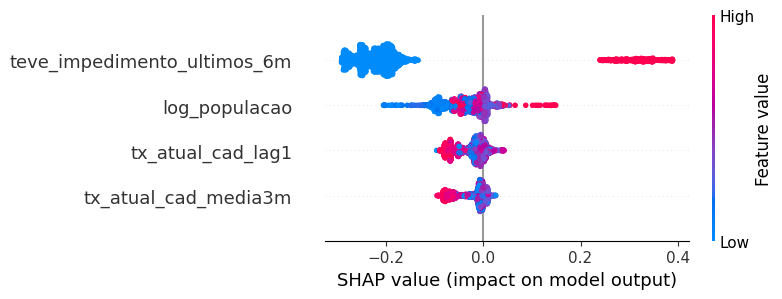

In [8]:
shap_values_classe1 = shap_values[:, :, 1]

shap.summary_plot(shap_values_classe1, X_val, feature_names=features)

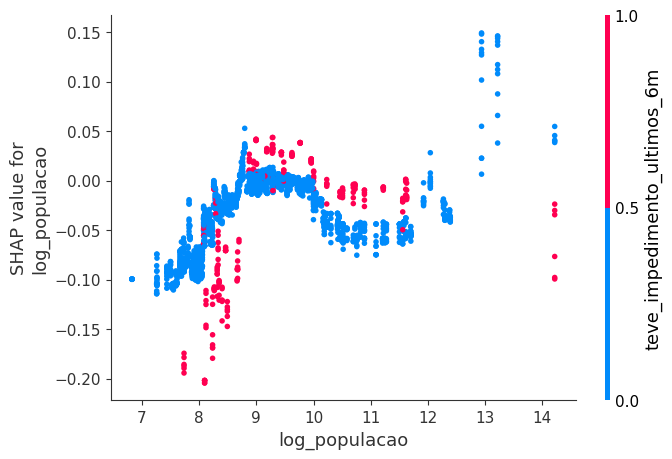

In [9]:
shap.dependence_plot("log_populacao", shap_values_classe1, X_val, feature_names=features)